## **<center>New York Yellow Taxi</center>**
### **<center>Data Cleaning Project</center>**
#### **<center>Part One</center>**




## Table of Contents


1. Introduction

2. Uploading Dataset

3. Structural Normalization

4. Removal of non-informative column

5. Duplicate Removal

6. Data Profiling

7. Null Handing

8. Standardization

9. Outlier Detection And Treatment

10. Validation Checks

11. Conclusion

12. Refernces

## 1. Introduction

Taxis are an essential part of urban transportation and are used on a daily basis all around the world. They are quick and comfortable but more expensive compared to public transportation such as trams and buses.

In this project, we clean and validate New York City Yellow Taxi data from 2020, a year considered particularly challenging and less busy for taxi drivers due to the COVID-19 pandemic. Various aspects of Yellow Taxi operations are examined, including pickup and drop-off times, number of passengers, trip distances, payment types, and total fares, among others.

This project is the first part of the New York Yellow Taxis analysis in which we are going validate the data and prepare it for anaylsis.

## 2. Uploading Datasets

The New York Yellow Taxi records are real-world datasets published monthly. In the first step, since all 12 datasets share the same columns, we upload and stack them vertically to produce a single DataFrame.

In [185]:
import pandas as pd
import numpy as np
import pyarrow
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
nytaxi = pd.concat([
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\jan.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\feb.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\mar.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\apr.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\may.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\jun.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\jul.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\aug.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\sep.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\oct.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\nov.parquet"),
               pd.read_parquet(r"E:\Python environments\nytaxi\datasets\dec.parquet")
], ignore_index=True)

In [186]:
print("== SHAPE OF DATASET ==")
rows, cols = nytaxi.shape

print(f" • Rows: {rows}")
print(f" • Columns: {cols}")
print(f" • Memory: {nytaxi.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

print("\n" + "_" * 81)
print("COLUMN DETAILS".center(81))
print("_" * 81)

summary = pd.DataFrame({
        'DataType': nytaxi.dtypes,
        'Non-Null': nytaxi.count(),
        'Null': nytaxi.isnull().sum(),
        'Null%': (nytaxi.isnull().sum() / 
                  len(nytaxi) * 100).round(2),
        'Unique': nytaxi.nunique()
    })

summary


== SHAPE OF DATASET ==
 • Rows: 24649092
 • Columns: 19
 • Memory: 4.61 GB

_________________________________________________________________________________
                                  COLUMN DETAILS                                 
_________________________________________________________________________________


,DataType,Non-Null,Null,Null%,Unique
VendorID,int64,24649092,0,0.00,4
tpep_pickup_datetime,datetime64[us],24649092,0,0.00,11776036
tpep_dropoff_datetime,datetime64[us],24649092,0,0.00,11776414
passenger_count,float64,23839125,809967,3.29,10
trip_distance,float64,24649092,0,0.00,7375
RatecodeID,float64,23839125,809967,3.29,7
store_and_fwd_flag,object,23839125,809967,3.29,2
PULocationID,int64,24649092,0,0.00,262
DOLocationID,int64,24649092,0,0.00,263
payment_type,int64,24649092,0,0.00,6


This dataset contains 24.6 million rows, 19 columns, and occupies 4.61 GB of memory. Most core variables such as - pickup/dropoff timestamps, locations, fares, taxes, and total amount - are fully populated with no missing values. 
However, several variables such as *passenger_count, RatecodeID, store_and_fwd_flag, and congestion_surcharge* have about 3.29% missing values (nearly 810000 rows). The *airport_fee* column is almost entirely null, with nearly 100% missing values.  Numerical fare-related columns show wide variability. Overall, the data needs a lot of cleaning and validation before it can be used for proper analysis or modeling.

## 3. Structural Normalization

**Fixing Columns Data Types**

The data types of two columns—namely, *passenger_count* (the number of passengers) and *RatecodeID* (the final rate code that affects the charge at the end of the trip)—are currently float. These columns might cause errors in future deep analysis if their current data types are retained. Therefore, we convert their data types from float to 'Int64'.

The data types of three columns such as *store_and_fwd_flag* (indicating whether trip data was temporarily stored in the vehicle's memory due to poor connectivity), *payment_type*, and *VendorID* (A value that indicates the LPEP provider providing the record) are object, float and int respectively. Since their values are categorical per se, we convert them to categorical data type. These columns represent discrete categories rather than numerical values.

Variables such as *PULocationID* (Pickup Location ID) and *DOLocationID* (Drop-off Location ID) represent zone identifiers. Therefore, we convert them to categorical data types to prevent accidental numeric operations. This also helps clarify intent, save more memory, and ensure correct grouping behavior in later analyses and dashboard creation.

*RatecodeID Reference*: 

1 = Standard rate

2 = JFK

3 = Newark

4 = Nassau/Westchester

5 = Negotiated fare

6 = Group ride

In [187]:
nytaxi['passenger_count'] = nytaxi['passenger_count'].astype('Int64')
nytaxi['RatecodeID'] = nytaxi['RatecodeID'].astype('Int64')

nytaxi['store_and_fwd_flag'] = nytaxi['store_and_fwd_flag'].astype('category') 
nytaxi['payment_type'] = nytaxi['payment_type'].astype('category')  
nytaxi['VendorID'] = nytaxi['VendorID'].astype('category')  

nytaxi["PULocationID"] = nytaxi["PULocationID"].astype("category")
nytaxi["DOLocationID"] = nytaxi["DOLocationID"].astype("category")


***DATA TYPE INSPECTION***

In [188]:
assert nytaxi['passenger_count'].dtype == 'Int64', "passenger_count not Int64!"
assert nytaxi['RatecodeID'].dtype == 'Int64', "RatecodeID not Int64!"

assert nytaxi['store_and_fwd_flag'].dtype == 'category', "store_and_fwd_flag not category!"
assert nytaxi['payment_type'].dtype == 'category' , "payment_type not category!"
assert nytaxi['VendorID'].dtype == 'category', "VendorID not category!"


print("All those already converted Data types optimized and verified successfully!")

All those already converted Data types optimized and verified successfully!


## 4. Removal of non-informative column

**Removing Column**

Almost 100 percent of the *airport_fee* column contains missing values and adds no analytical signal to this dataset. Therefore, it is the primary candidate for removal from the dataset.

In [189]:
print(f"Null Values in airport_fee column")
print(
    nytaxi['airport_fee']
        .isna()
        .sum() 
        *100 
        / len(nytaxi['airport_fee'])
)


Null Values in airport_fee column
99.99991480416398


In [190]:
(
    nytaxi.drop(columns=['airport_fee']
                ,inplace=True)
)
print(f"• The airport_fee column was successfully removed from the dataset.")

• The airport_fee column was successfully removed from the dataset.


## 5. Duplicate Removal

At this stage, we remove duplicate records before proceeding with row-level cleaning. Because duplicates can interfere with the analysis by distorting missing-value ratios, inflating counts, and biasing summary statistics and distributions.

In [191]:
print("DUPLICATE DETECTION".center(40))
print("-" * 40)

if nytaxi.duplicated().any():
    dup_pct = (nytaxi.duplicated().sum() * 100 / len(nytaxi)).round(3)
    dup_count = nytaxi.duplicated().sum()
    print(f"{dup_pct}% duplicates detected {dup_count:,} rows")
else:
    print("No duplicates found")


          DUPLICATE DETECTION           
----------------------------------------
0.053% duplicates detected 12,950 rows


In [192]:
def drop_dup():
    nytaxi.drop_duplicates(inplace=True)
    return nytaxi
nytaxi = drop_dup()

***DROP DUPLICATES INSPECTION***

In [193]:
print("DUPLICATE DETECTION") 
print("-" * 20)

if nytaxi.duplicated().any():
    dup_count = nytaxi.duplicated().sum()
    print(f" {dup_count:,} duplicates detected")
else:
    print("0 duplicates found")

DUPLICATE DETECTION
--------------------
0 duplicates found


## 6. Data Profiling

In [194]:
print("\n" + "_" * 41)
print("COLUMN DETAILS".center(41))
print("_" * 41)

summary = pd.DataFrame({
        'Null': nytaxi.isnull().sum(),
        'Null%': (nytaxi.isnull().sum() / len(nytaxi) * 100).round(2),
    })

summary


_________________________________________
              COLUMN DETAILS             
_________________________________________


,Null,Null%
VendorID,0,0.00
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
passenger_count,797018,3.24
trip_distance,0,0.00
RatecodeID,797018,3.24
store_and_fwd_flag,797018,3.24
PULocationID,0,0.00
DOLocationID,0,0.00
payment_type,0,0.00


The null values cluster in the *passenger_count, RatecodeID, store_and_fwd_flag, and congestion_surcharge* columns, totaling nearly 800,000 rows. This indicates that the null values make up over 3 percent of the dataset.

In [195]:
subset = nytaxi[[
    'passenger_count',
    'trip_distance', 
    'fare_amount', 
    'tip_amount',
    'tolls_amount']]

pd.options.display.float_format = '{:.2f}'.format
subset.describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,23839124.00,24636142.00,24636142.00,24636142.00,24636142.00
mean,1.47,3.53,12.66,2.08,0.30
std,1.11,325.12,274.16,2.61,1.60
min,0.00,-30.62,-1259.00,-493.22,-40.00
25%,1.00,0.99,6.50,0.00,0.00
50%,1.00,1.65,9.00,1.92,0.00
75%,1.00,3.00,14.00,2.76,0.00
max,9.00,350914.89,998310.03,1393.56,925.50


The minimum and maximum values of *passenger_count* indicate the presence of outliers. They are likely caused by data-entry errors or system defaults. Most taxi trips involve a single passenger or fewer than five passengers. In addition, New York City yellow taxis are licensed to carry up to five or six passengers. Therefore, any values outside this range are considered invalid.

Examining key statistical measures of *trip_distance*, such as the minimum, maximum, and standard deviation, reveals several unrealistic values. For example, negative distances (e.g., –30.62 miles) are physically impossible. Extremely large maximum values and unusually high standard deviations further confirm the presence of severe outliers.

The *fare_amount* variable also shows major issues. Negative fares are generally invalid unless they represent refunds, while extremely large fares suggest data corruption or unit errors. A reasonable fare range is approximately 3 to 500 USD. Values outside this range—such as a maximum fare close to 1 million USD — are clearly unrealistic and indicate severe anomalies.

Similarly, *tip_amount* and *tolls_amount* contain extreme negative and unusually large values. They point to possible input or system errors. In practice, most tips are well below 5 USD, and very large toll amounts are not realistic for typical taxi trips.

Summary

Based on these statistical measures, negative and physically impossible values in *passenger_count, trip_distance, fare_amount, tip_amount, and tolls_amount* are classified as invalid and likely caused by data-entry or system errors. At this stage, no values have been removed or modified. Instead, outliers have been identified and flagged. They will be addressed in later cleaning steps after proper validation.

In [196]:
(
    nytaxi[['fare_amount', 'trip_distance']]
    .agg(['skew', 'kurtosis'])
)

,fare_amount,trip_distance
skew,2855.53,738.36
kurtosis,9031406.75,649526.12


The skewness and kurtosis values for *fare_amount* and *trip_distance* in the NYC Taxi dataset show extreme right skewness and very high kurtosis. Both variables have heavily right-skewed distributions with long tails and severe outliers. This supports the extreme anomalies already observed. They are more likely due to data errors rather than legitimate taxi trips.

Given the presence of such extreme values, skewness and kurtosis are used here primarily as diagnostic indicators rather than as measures for satisfying strict modeling assumptions.

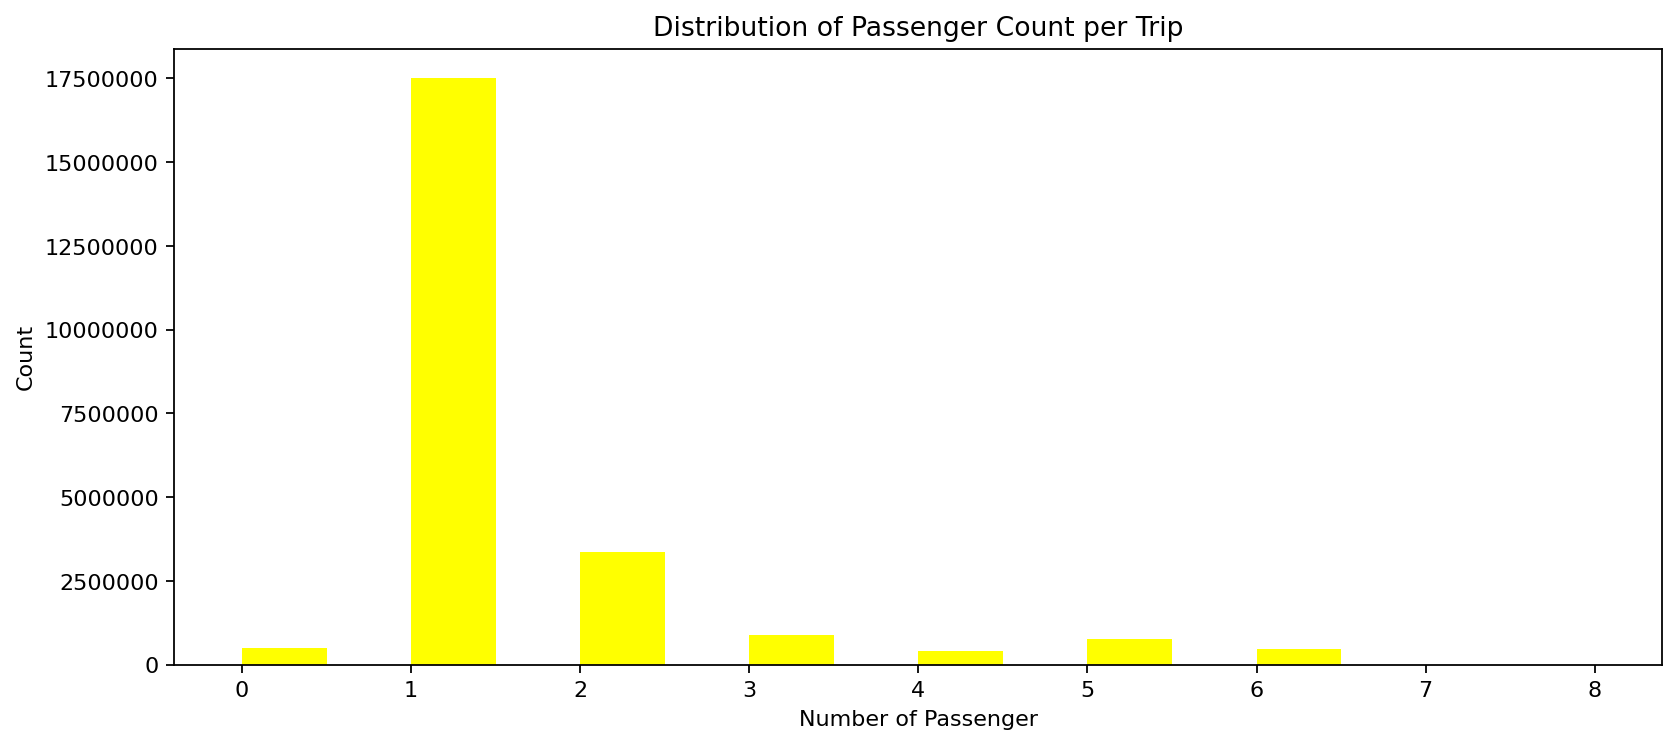

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5), dpi=160)
plt.hist(nytaxi['passenger_count'], bins=range(0, 9), color='yellow', width=0.5 )
plt.title('Distribution of Passenger Count per Trip')
plt.xlabel('Number of Passenger')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='y')
plt.show()


The passenger count distribution is highly right-skewed. It shows that the vast majority of trips carrying between one and three passengers. A median value of one confirms that single-passenger trips dominate the dataset. Values of zero and nine occur extremely rarely. They are most likely the result of data-entry errors or unusual cases, such as shared or misrecorded trips. These outliers inflate the overall range but do not reflect typical taxi usage.

Some zero-passenger trips may be due to sensor issues or missing data. However, for analytical consistency, these records are treated as invalid.

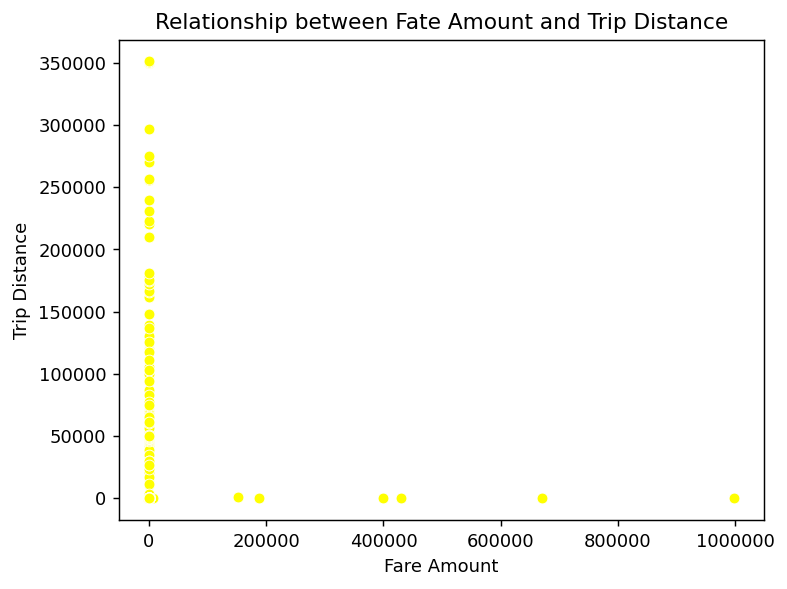

In [198]:
plt.figure( dpi=130)
sns.scatterplot(x=nytaxi['fare_amount'], y=nytaxi['trip_distance'], color='yellow' )
plt.ticklabel_format(style='plain', axis='x')
plt.title('Relationship between Fate Amount and Trip Distance')
plt.xlabel('Fare Amount')
plt.ylabel('Trip Distance')
plt.show()

The scatterplot reveals extreme and impossible values in both fare amount and trip distance. It indicates the presence of data entry errors, anomalies, system failure. These outliers and anomalies distort the scale and obscure the typical fare–distance relationship. Therefore, it highlights the need for data cleaning.

## 7. Null Handling 


**Before**

In [199]:
null_summary = pd.DataFrame({
     'Null': nytaxi.isna().sum()   
})

null_summary.index.name = 'Column'
display(null_summary)

,Null
Column,
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,797018
trip_distance,0
RatecodeID,797018
store_and_fwd_flag,797018
PULocationID,0
DOLocationID,0


**After**

In [200]:
def drop_null():
    nytaxi.dropna(inplace=True)
    return nytaxi
nytaxi = drop_null()

In [201]:
display (
    nytaxi.isna()
    .sum()
    .rename_axis("Column")
    .to_frame("Null")
)

,Null
Column,
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0


Rows with missing values (n = 797,018) in key trip attributes -*passenger_count, RatecodeID, store_and_fwd_flag, and congestion_surcharge*- were removed. These rows represent approximately 3.3% of the dataset. They were excluded to ensure record completeness and reduce computational overhead.

Although 797,018 missing values were detected across key columns, these were distributed across 809,968 rows. All rows containing at least one missing value were removed, resulting in a reduction of 809,968 records.

## 8. Standardization And Corrections

**store_and_fwd_flag** 

store_and_fwd_flag has two values; N = No and Y = Yes. For more readibility and for later creation of dashboard, we convert them to Yes and No. 

In [202]:
nytaxi["store_and_fwd_flag"] = (
    nytaxi["store_and_fwd_flag"]
    .map({"Y": "Yes", "N": "No"})
    .astype("category")
)

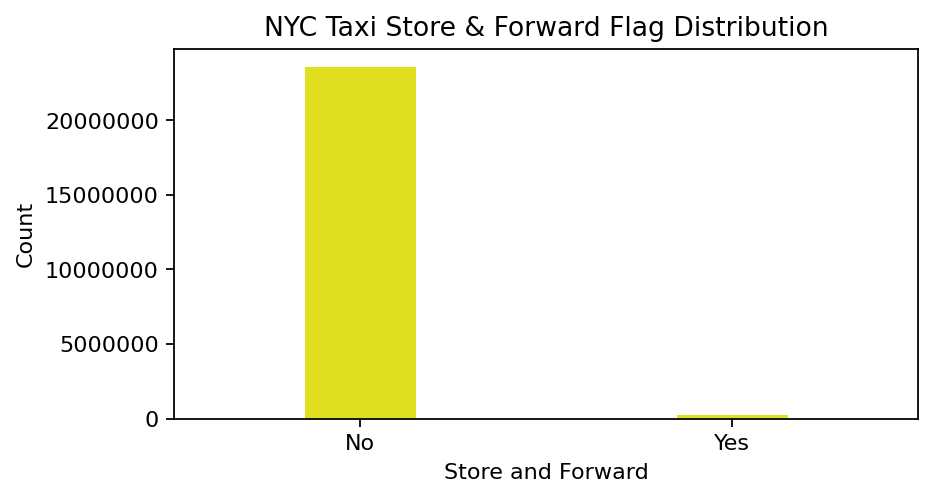

In [203]:
plt.figure(figsize=(6,3),dpi=160)
sns.countplot(x=nytaxi['store_and_fwd_flag'], color='yellow', width=0.3)
plt.title('NYC Taxi Store & Forward Flag Distribution') 
plt.xlabel('Store and Forward')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

**payment_type**

**Before**

In [204]:
(
    nytaxi.payment_type
    .value_counts()
    .sort_values()
)

payment_type
0           0
5          15
4       82365
3      144485
2     6148485
1    17463774
Name: count, dtype: int64

**After**

In [205]:
import pandas as pd

mapping = {
    1: "Credit card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip"
}

nytaxi["payment_type"] = (
    pd.to_numeric(nytaxi["payment_type"].astype("object"), errors="coerce")
    .map(mapping)
    .fillna("Unknown")
    .astype("category")
)
nytaxi['payment_type'].value_counts()

payment_type
Credit card    17463774
Cash            6148485
No Charge        144485
Dispute           82365
Unknown              15
Name: count, dtype: int64

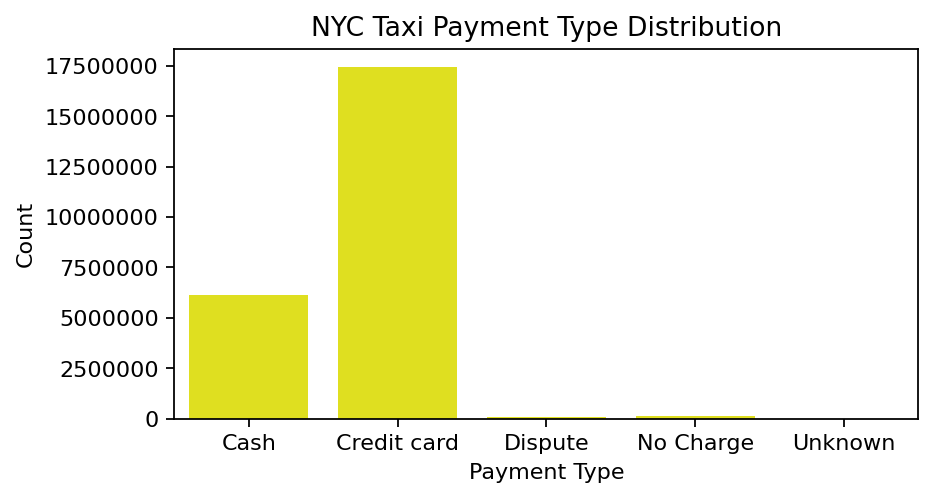

In [206]:
plt.figure(figsize=(6,3),dpi=160)
sns.countplot(x=nytaxi['payment_type'], color='yellow')
plt.title('NYC Taxi Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

*payment_type* is a purely categorical variable. Converting numeric codes into meaningful labels helps improve both statistical analysis and dashboard interpretation. These codes have no numeric meaning. Therefore, leaving them as integers can lead to confusing dashboards and the risk of invalid numeric operations. To avoid these issues, we convert them to names such as *Credit card* and *Cash*. This improves interpretability and preserves statistical validity.

## 9. Outlier Detection And Treatment

In [207]:
skewness = nytaxi.select_dtypes(include='number').skew()

skew_df = (
    pd.DataFrame(skewness, columns=["Skewness"])
      .reset_index()
      .rename(columns={"index": "Feature"})
)
skew_df

,Column,Skewness
0,passenger_count,2.56
1,trip_distance,3009.45
2,RatecodeID,105.01
3,fare_amount,2809.89
4,extra,4881.45
5,mta_tax,4882.53
6,tip_amount,26.22
7,tolls_amount,65.45
8,improvement_surcharge,-15.31
9,total_amount,2482.30


These skewness results show that most numeric columns in the dataset are extremely right-skewed. It means a small number of very large values dominate the distributions. Variables like *trip_distance, fare_amount, total_amount, extra, and mta_tax* have massive positive skew. It suggests the presence of heavy tails and extreme outliers such as very long trips, or high fares. Skewness for categorical identifiers such as *RatecodeID* is not analytically meaningful but that is reported only for completeness. This is normal for taxi data, where most trips are short and cheap but a few are very long or expensive. A few columns show left skew such as *improvement_surcharge* and *congestion_surcharge*, likely due to fixed or capped values. Overall, the skewness confirms that outliers are a structural feature of the data, not necessarily errors.

In [208]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Select variables
X = nytaxi[['passenger_count',
            'trip_distance',
            'fare_amount',
            'extra',
            'mta_tax',
            'tip_amount',
            'tolls_amount',
           'improvement_surcharge',
            'total_amount',
           'congestion_surcharge']]

X_scaled = StandardScaler().fit_transform(X)

# Fit Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,   
    random_state=42
)

nytaxi['outlier'] = iso.fit_predict(X_scaled)

nytaxi['outlier'] = nytaxi['outlier'].map({1: 'No', -1: 'Yes'})

outliers = nytaxi[nytaxi['outlier'] == 1]

In [209]:
nytaxi['outlier'].value_counts()

outlier
No     22647199
Yes     1191925
Name: count, dtype: int64

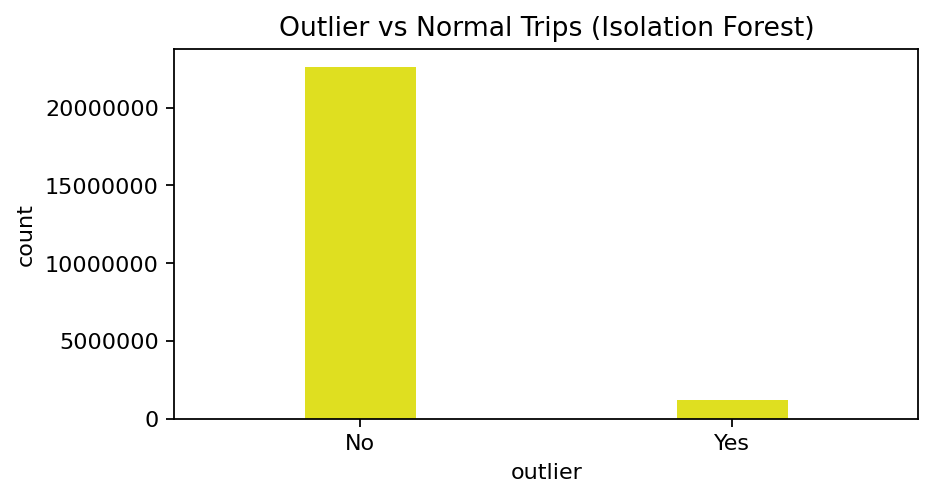

In [210]:
plt.figure(figsize=(6,3),dpi=160)
sns.countplot(x=nytaxi['outlier'], color='yellow', width=0.3)
plt.title('Outlier vs Normal Trips (Isolation Forest)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

This dataset has nearly 1.2 million outliers and anomalies. However, we will not remove all of them. We selectively remove those that we think are truly outliers and do not serve our analytical purposes.

### tpep_dropoff_datetime 

In [211]:
(
    (nytaxi["tpep_dropoff_datetime"] 
            < nytaxi["tpep_pickup_datetime"]).sum()
)

181

There are 181 rows that dropoff time is earlier than pickup time. This is logically impossible in real-world trips. Therefore, they will be removed.

In [212]:
nytaxi = nytaxi[
    nytaxi["tpep_dropoff_datetime"] >= nytaxi["tpep_pickup_datetime"]
]

**Before**

* Checking after the year 2020:

In [213]:
(
    nytaxi['tpep_dropoff_datetime']
    .between(pd.Timestamp('2020-12-31'), 
             pd.Timestamp('2025-01-01'))
    .sum()
)

41622

A total of 41,622 records have drop-off timestamps beyond the year 2020. These records were treated as outliers and removed to prevent distortion of subsequent analyses.

**After**

In [214]:
nytaxi = nytaxi[
    nytaxi['tpep_dropoff_datetime'].between(
        '2020-01-01', '2021-01-01', inclusive='left'
    )
]


* Validating records after the year 2020:

In [215]:
(
    nytaxi['tpep_dropoff_datetime']
    .between(pd.Timestamp('2021-01-01'), 
             pd.Timestamp('2025-01-01'))
    .sum()
)

0

* Validating records before the year 2020:

In [216]:
(
    nytaxi['tpep_dropoff_datetime']
    .between(pd.Timestamp('2001-01-01'), 
             pd.Timestamp('2020-01-01'))
    .sum()
)

0

### tpep_pickup_datetime

**Before**
* Checking the presence of recored before the year 2020:

In [217]:
(
    nytaxi['tpep_pickup_datetime']
    .between(pd.Timestamp('2001-12-31'), 
             pd.Timestamp('2020-01-01'))
    .sum()
)

70

There are 70 row that were recoreded before 2020-01-01 00:00:01. Therefore, they are outliers and they will be removed

**After**

In [218]:
nytaxi = nytaxi[
    nytaxi['tpep_pickup_datetime'].between(
        '2020-01-01', '2021-01-01', inclusive='left'
    )
]


* Validating the records before the year 2020:

In [219]:
(
    nytaxi['tpep_pickup_datetime']
    .between(pd.Timestamp('2001-12-31'), 
             pd.Timestamp('2019-12-31'))
    .sum()
)

0

* Validating the records after the year 2020:

In [220]:
(
    nytaxi['tpep_pickup_datetime']
    .between(pd.Timestamp('2021-01-01'), 
             pd.Timestamp('2025-01-01'))
    .sum()
)

0

All records outside the year 2020 were removed, so the dataset now contains only data from 2020.

### passenger_count

**Before**

In [221]:
nytaxi['passenger_count'].value_counts()

passenger_count
1    17510926
2     3349053
3      872626
5      751700
0      489379
6      474515
4      390086
7          91
8          58
9          51
Name: count, dtype: Int64

**After**

In [222]:
def drop_outliers(nytaxi):
    return nytaxi[nytaxi['passenger_count'].between(1, 5)]
nytaxi = drop_outliers(nytaxi)
nytaxi['passenger_count'].value_counts()

passenger_count
1    17510926
2     3349053
3      872626
5      751700
4      390086
Name: count, dtype: Int64

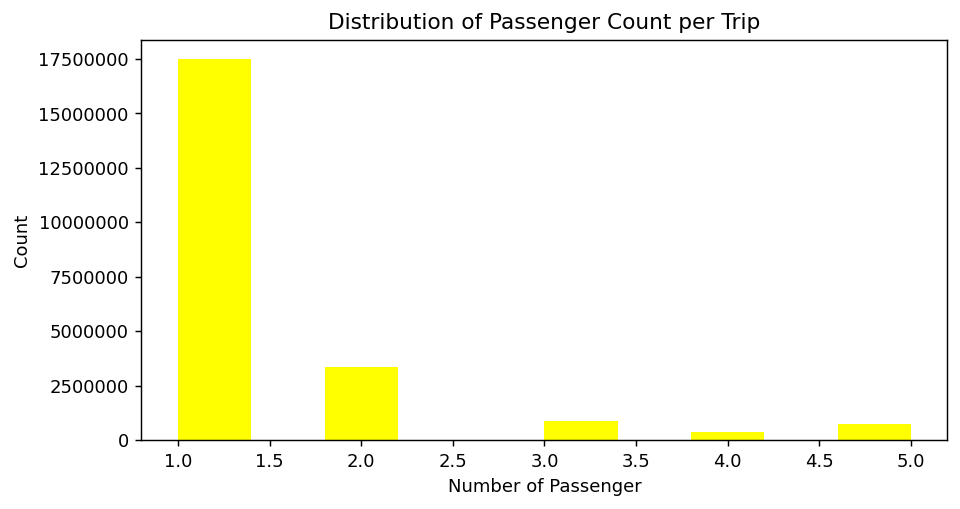

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4), dpi=130)
plt.hist(nytaxi['passenger_count'], color='yellow', )
plt.ticklabel_format(style='plain', axis='y')
plt.title('Distribution of Passenger Count per Trip')
plt.xlabel('Number of Passenger')
plt.ylabel('Count')
plt.show()


We consider for *passenger_count* a range between 1-5 passengers. Any number of passengers outside this range will be an outlier or anomaly. Values of 0 or unusually high counts occurred extremely rarely and are inconsistent with standard New York City yellow taxi vehicle capacity.

### trip_distance

**Before**

In [224]:
(
    nytaxi['trip_distance']
    .agg(['min', 'median', 'mean', 'max'])
)

min         -22.18
median        1.60
mean          2.75
max      167329.45
Name: trip_distance, dtype: float64

**After**

In [225]:
nytaxi = nytaxi[nytaxi['trip_distance'].between(0,100)]

(
    nytaxi['trip_distance']
    .agg(['min', 'median', 'mean', 'max'])
)

min       0.00
median    1.60
mean      2.73
max      99.87
Name: trip_distance, dtype: float64

Trips with negative distances and distances greater than 100 miles were removed as physically implausible. Trips between 50 and 100 miles were retained. They are rare but valid long-distance trips. Moreover, Short trips less than 1 mile are kept, as they are common and expected in dense urban environments such as New York City.

### fare_amount

**Before**

In [226]:
(
    nytaxi['fare_amount']
    .agg(['min', 'median', 'mean','max'])
)

min       -1259.00
median        9.00
mean         12.14
max      998310.03
Name: fare_amount, dtype: float64

**After**

In [227]:
nytaxi = nytaxi[nytaxi['fare_amount'].between(2,300)]

(
    nytaxi['fare_amount']
    .agg(['min', 'median', 'mean', 'max'])
)

min        2.00
median     9.00
mean      12.11
max      300.00
Name: fare_amount, dtype: float64

Trips with negative fares and fares that are greater than 300 USD were removed as invalid. Negative fares were considered anomalies and are not meaningful for completed trips. Therefore, they were removed as well. Fares above 300 USD represent extreme and implausible values in the context of NYC yellow taxi trips in 2021. Fares between 2 and 300 USD were kept.

### extra
This miscellaneous extras and surcharges only include the 0.50 and 1 USD rush hour and overnight charges)

**Before**

In [228]:
(
    nytaxi['extra']
    .agg(['min', 'median', 'mean', 'max'])
)

min         -27.00
median        0.50
mean          1.08
max      500000.80
Name: extra, dtype: float64

**After**

In [229]:
nytaxi = nytaxi[nytaxi['extra'].between(0,10)]

(
    nytaxi['extra']
    .agg(['min', 'median', 'mean', 'max'])
)


min      0.00
median   0.50
mean     1.06
max      9.50
Name: extra, dtype: float64

The extra variable represents fixed surcharges such night and peak-hour fees. Values below 0 and above 10 USD were removed as invalid, as legitimate surcharge amounts are small and bounded. Less than 50 values are greater than 10 USD. It indicates data corruption rather than valid charges.

### mta_tax
MTA tax is 0.50 USD that is automatically triggered based on the metered rate in use

**Before**

In [230]:
(
    nytaxi['mta_tax']
    .agg(['min', 'median', 'mean', 'max'])
)

min      0.00
median   0.50
mean     0.50
max      3.30
Name: mta_tax, dtype: float64

**After**

In [231]:
nytaxi = nytaxi[nytaxi['mta_tax'].isin([0.0, 0.5])]
nytaxi['mta_tax'].agg(['min', 'median', 'mean', 'max'])

min      0.00
median   0.50
mean     0.50
max      0.50
Name: mta_tax, dtype: float64

The MTA tax is a fixed 0.50 USD surcharge applied to most trips. Values of 0.00 and 0.50 USD were retained as valid. Values outside this range were removed as invalid.

### tip_amount
Tip amount are automatically populated for credit card tips and cash tips are excluded)

**Before**

In [232]:
(
    nytaxi['tip_amount']
    .agg(['min', 'median', 'mean', 'max'])
)

min         0.00
median      1.92
mean        2.10
max      1100.00
Name: tip_amount, dtype: float64

**After**

In [233]:
nytaxi = nytaxi[nytaxi['tip_amount'].between(0,50)]
nytaxi['tip_amount'].agg(['min', 'median', 'mean', 'max'])

min       0.00
median    1.92
mean      2.10
max      50.00
Name: tip_amount, dtype: float64

In [234]:
nytaxi['tip_amount'].quantile([0.99, 0.999])

0.99   12.28
1.00   19.78
Name: tip_amount, dtype: float64

Since tips are behavioral, not fixed, we keep the lower bound 0 and upper bound 50 USD. 0 tips could be valid  and removing them would bias results. 50 USD tips are rare but still possible for airport trips, long-distance rides, or even generous rounding. Outside this range will be considered outliers and anomalies and removed.

An analysis of the *tip_amount* distribution shows that 99 percen of tips are below 12.28 USD and 99.9 percent are below 19.78 USD. Therefore, tips above 20 are extremely rare. The maximum value exceeds 1,000 USD indicating clear anomalies.

### tolls_amount

**Before**

In [235]:
(
    nytaxi['tolls_amount']
    .agg(['min', 'median', 'mean', 'max'])
)

min       -6.12
median     0.00
mean       0.27
max      911.75
Name: tolls_amount, dtype: float64

**After**

In [236]:
def tolls_filtering(nytaxi):
    nytaxi=nytaxi[nytaxi['tolls_amount'].between(0, 20)]
    return nytaxi
nytaxi = tolls_filtering(nytaxi)

(
    nytaxi['tolls_amount']
    .agg(['min', 'median', 'mean', 'max'])
)

min       0.00
median    0.00
mean      0.26
max      20.00
Name: tolls_amount, dtype: float64

Tolls were retained in the range 0 and 20 USD. Zero tolls were kept as most trips do not incur tolls. Tolls over 20 USD were removed. Because they are indicating outliers or data corruption.

### improvement_surcharge

In [237]:
(
    nytaxi['improvement_surcharge']
    .agg(['min', 'median', 'mean', 'max'])
)

min      0.00
median   0.30
mean     0.30
max      0.30
Name: improvement_surcharge, dtype: float64

### total_amount 

In [238]:
(
    nytaxi['total_amount']
    .agg(['min', 'median', 'mean', 'max'])
)

min        2.00
median    14.16
mean      17.85
max      340.30
Name: total_amount, dtype: float64

Total trip amounts ranged from 2 to 340 USD. Trips over 300 USD were extremely rare but possible. Since only 140 rows values are over 300 USD, equivalent to 0.0006 percent. Therefore, its impact is tiny and were retained, as all fare components had been independently validated.

### congestion_surcharge 
Congestion surcharge for trips that start, end or pass through the congestion zone in Manhattan, south of 96th street. 2.50 USD is for non-shared trips in Yellow Taxis

In [239]:
(
    nytaxi['congestion_surcharge']
    .agg(['min', 'median', 'mean', 'max'])
)

min      0.00
median   2.50
mean     2.29
max      3.00
Name: congestion_surcharge, dtype: float64

Congestion surcharge values ranged from 0 to 3 USD, with a median of 2.50 USD. The 2.50 USD value corresponds to the standard congestion surcharge for non-shared Yellow Taxi trips. 0 USD reflects trips that did not enter the congestion zone or were exempt. The observed range and distribution are consistent with NYC congestion pricing policy. Therefore, no further filtering was required.

## 10. Validation Checks

In [240]:
print("------------ SHAPE OF DATASET ------------")
metrics = {
    'Metric': ('Rows',  'Memory'),
    '           '
    'Before': ('24.6M', '4.6 GB'),
    '           '
    'After': ('22.7M', '3.8 GB')
}
metrics1 = pd.DataFrame.from_dict(metrics)
print(metrics1.to_string(index=False))


print("\n" + "_" * 91)
print("Validation".center(91))
print("_" * 91)

summary = pd.DataFrame({
        'DataType': nytaxi.dtypes,
        'Row': nytaxi.shape[1],
        'Columns' : nytaxi.shape[0],
        'Non-Null': nytaxi.count(),
        'Unique': nytaxi.nunique(),
        'Null': nytaxi.isnull().sum(),
        'Duplicates': nytaxi.duplicated().sum()
    })

summary


------------ SHAPE OF DATASET ------------
Metric            Before            After
  Rows             24.6M            22.7M
Memory            4.6 GB           3.8 GB

___________________________________________________________________________________________
                                         Validation                                        
___________________________________________________________________________________________


,DataType,Row,Columns,Non-Null,Unique,Null,Duplicates
Column,,,,,,,
VendorID,category,19,22761013,22761013,2,0,0
tpep_pickup_datetime,datetime64[us],19,22761013,22761013,11222446,0,0
tpep_dropoff_datetime,datetime64[us],19,22761013,22761013,11230562,0,0
passenger_count,Int64,19,22761013,22761013,5,0,0
trip_distance,float64,19,22761013,22761013,5421,0,0
RatecodeID,Int64,19,22761013,22761013,7,0,0
store_and_fwd_flag,category,19,22761013,22761013,2,0,0
PULocationID,category,19,22761013,22761013,262,0,0
DOLocationID,category,19,22761013,22761013,263,0,0


## 11. Conclusion

After applying domain-informed cleaning rules, a series of validation and integrity checks were performed. All numeric variables were verified, and cross-column checks confirmed that total trip amounts reconcile with individual fare components. Categorical fields were also validated against known allowable values, such as *payment_type*. In addition, distributional patterns aligned well with expected New York City taxi behavior.

Only a small fraction of records was removed at each cleaning step. It indicates that the process corrected anomalies without distorting valid data. As a result, memory usage decreased from 4.6 GB to 3.8 GB, and the number of rows was reduced from over 24.6 million to 22.7 million. The *airport_fee* column was dropped because it was nearly 100% empty.

Overall, the cleaned dataset is internally consistent and ready for analysis. It is now suitable for downstream tasks such as fare prediction, demand analysis, and dashboard development to explore trip patterns by zone and time.


## 12. References
New York City Government. *TLC Trip Record Data*. Retrieved from:

https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page